In [2]:
pip install yfinance pandas

  Using cached cffi-2.0.0-cp312-cp312-win_amd64.whl.metadata (2.6 kB)
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 2.8 MB/s eta 0:00:01
   ------------------------------- -------- 1.3/1.7 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 3.3 MB/s eta 0:00:00
Using cached cffi-2.0.0-cp312-cp312-win_amd64.whl (183 kB)
  Attempting uninstall: cffi
    Found existing installation: cffi 1.17.1
    Uninstalling cffi-1.17.1:
      Successfully uninstalled cffi-1.17.1
Note: you may need to restart the kernel to use updated packages.


Task1

In [9]:
import yfinance as yf
import pandas as pd

ticker_symbol = "COMI.CA"

stock_data = yf.download(ticker_symbol, start="2024-01-01", end="2026-05-15")

if not stock_data.empty:
    print("\n=== Dataset Preview ===")
    print(stock_data.head())
    
    print("\n=== Dataset Info ===")
    print(stock_data.info())
    
    print("\n=== Dataset Shape ===")
    print(f"Number of Rows: {stock_data.shape[0]}")
    print(f"Number of Columns: {stock_data.shape[1]}")
    
    # Save the data to a CSV file to use later in Task 2 (Data Cleaning)
    stock_data.to_csv("COMI_historical_data.csv")
    print("\n✅ Data successfully saved to COMI_historical_data.csv")
else:
    print("❌ No data found.")

[*********************100%***********************]  1 of 1 completed


=== Dataset Preview ===
Price           Close       High        Low       Open   Volume
Ticker        COMI.CA    COMI.CA    COMI.CA    COMI.CA  COMI.CA
Date                                                           
2024-01-02  68.870331  68.879529  66.626456  66.810384  7829088
2024-01-03  67.959908  69.063449  67.702415  68.870329  3692464
2024-01-04  68.971489  69.146219  67.867948  67.959909  8593039
2024-01-08  68.741577  69.431292  68.051862  68.971482  4558612
2024-01-09  68.668015  69.146221  68.208205  68.741586  7261794

=== Dataset Info ===
<class 'pandas.DataFrame'>
DatetimeIndex: 570 entries, 2024-01-02 to 2026-05-14
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, COMI.CA)   570 non-null    float64
 1   (High, COMI.CA)    570 non-null    float64
 2   (Low, COMI.CA)     570 non-null    float64
 3   (Open, COMI.CA)    570 non-null    float64
 4   (Volume, COMI.CA)  570 non-null    i

Task2

In [10]:
import pandas as pd


df = pd.read_csv("COMI_historical_data.csv", header=[0, 1], index_col=0)


df.columns = [col[0] for col in df.columns]

df.reset_index(inplace=True)

df.rename(columns={df.columns[0]: 'Date'}, inplace=True)

df['Date'] = pd.to_datetime(df['Date'])

print(" Data formatting complete. Current Columns:", df.columns.tolist())

missing_values_count = df.isnull().sum().sum()
print(f"\n Searching for missing values... Found: {missing_values_count}")

if missing_values_count > 0:
    df.fillna(method='ffill', inplace=True)
    print("✅ Missing values handled using Forward Fill.")
else:
    print("✅ No missing values to handle.")

duplicates_count = df.duplicated().sum()
print(f"\n🔍 Searching for duplicate rows... Found: {duplicates_count}")

if duplicates_count > 0:
    df.drop_duplicates(inplace=True)
    print("✅ Duplicates removed successfully.")
else:
    print("✅ No duplicates found.")

df.to_csv("COMI_cleaned_data.csv", index=False)

 Data formatting complete. Current Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

 Searching for missing values... Found: 0
✅ No missing values to handle.

🔍 Searching for duplicate rows... Found: 0
✅ No duplicates found.


Task3

In [11]:
df = pd.read_csv("COMI_cleaned_data.csv")

df['Date'] = pd.to_datetime(df['Date'])

print("--- 1. Basic Statistics Summary ---")
print(df.describe())

df['SMA_50'] = df['Close'].rolling(window=50).mean()

print("\n--- 2. Recent Trend Analysis (Last 5 Days) ---")
print("Comparing the Closing Price to the 50-Day Moving Average (SMA_50):")
print(df[['Date', 'Close', 'SMA_50']].tail())

volume_mean = df['Volume'].mean()
volume_std = df['Volume'].std()
outlier_threshold = volume_mean + (3 * volume_std)

outliers = df[df['Volume'] > outlier_threshold]

print(f"\n--- 3. Outliers Detected (Extremely High Volume Days) ---")
print(f"Found {len(outliers)} days with abnormal trading volume.")
if not outliers.empty:
    print(outliers[['Date', 'Close', 'Volume']].sort_values(by='Volume', ascending=False).head())

df.to_csv("COMI_eda_data.csv", index=False)

--- 1. Basic Statistics Summary ---
                             Date       Close        High         Low  \
count                         570  570.000000  570.000000  570.000000   
mean   2025-03-12 02:18:56.842105   86.955527   87.989754   86.004153   
min           2024-01-02 00:00:00   65.532112   66.672439   64.373389   
25%           2024-08-14 06:00:00   73.234543   74.030027   72.637708   
50%           2025-03-07 12:00:00   77.264313   77.793659   76.531092   
75%           2025-10-15 18:00:00   98.589293   99.389846   97.641016   
max           2026-05-14 00:00:00  143.509995  144.929993  142.699997   
std                           NaN   19.589799   19.867537   19.300579   

             Open        Volume  
count  570.000000  5.700000e+02  
mean    86.843695  3.520600e+06  
min     65.392444  0.000000e+00  
25%     73.234542  1.607922e+06  
50%     77.259683  2.597084e+06  
75%     98.372478  4.304348e+06  
max    143.509995  2.045855e+07  
std     19.512199  3.154948e+06  


Task4

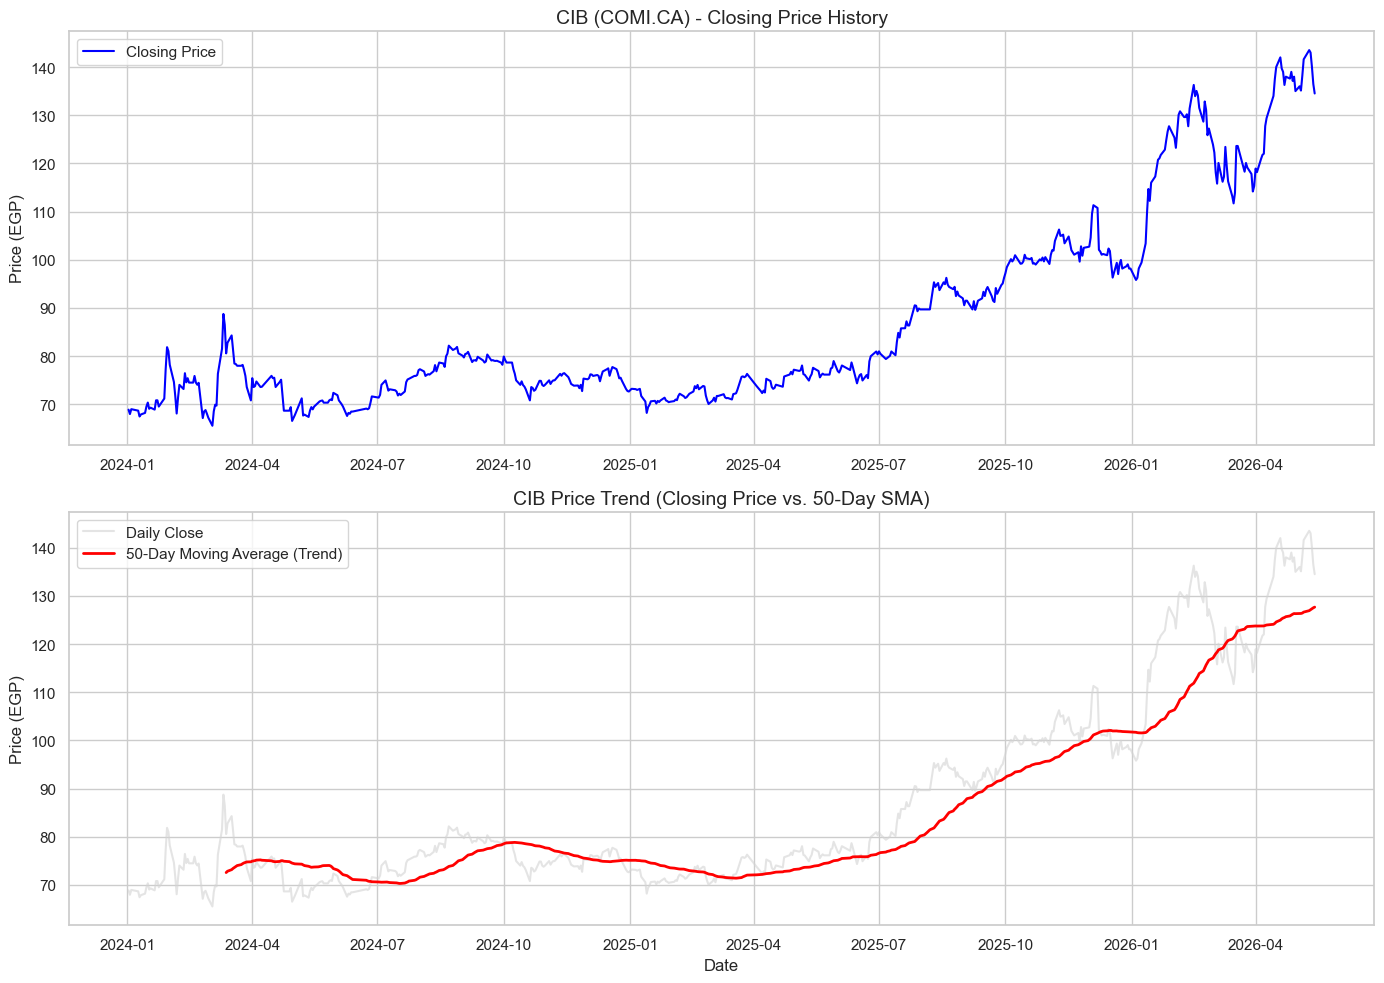

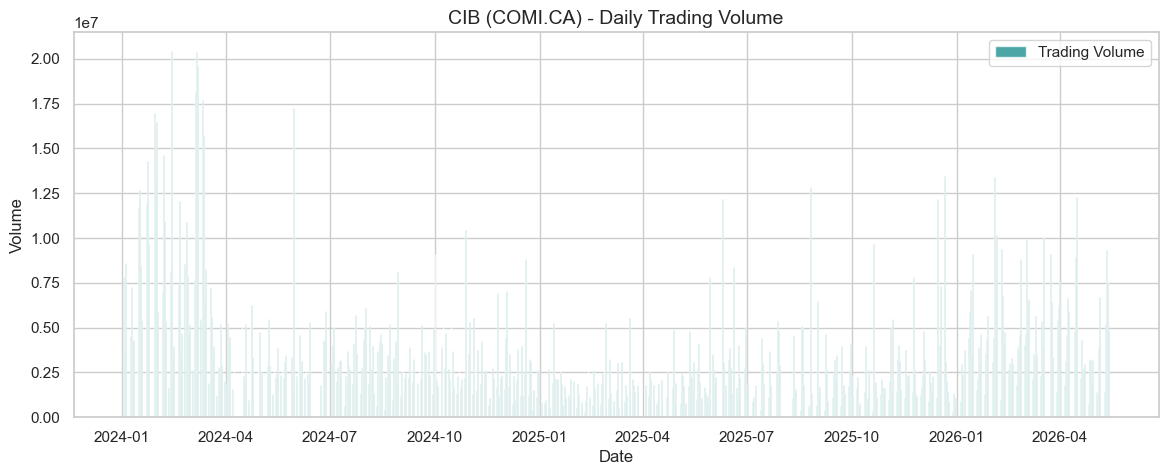

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("COMI_eda_data.csv")
df['Date'] = pd.to_datetime(df['Date'])

sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 10))


plt.subplot(2, 1, 1)
plt.plot(df['Date'], df['Close'], label='Closing Price', color='blue', linewidth=1.5)
plt.title('CIB (COMI.CA) - Closing Price History', fontsize=14)
plt.ylabel('Price (EGP)')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(df['Date'], df['Close'], label='Daily Close', color='lightgray', alpha=0.6)
plt.plot(df['Date'], df['SMA_50'], label='50-Day Moving Average (Trend)', color='red', linewidth=2)
plt.title('CIB Price Trend (Closing Price vs. 50-Day SMA)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (EGP)')
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.bar(df['Date'], df['Volume'], color='teal', alpha=0.7, label='Trading Volume')
plt.title('CIB (COMI.CA) - Daily Trading Volume', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.show()



Task5

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("COMI_eda_data.csv")

df['Target_Next_Close'] = df['Close'].shift(-1)

df.dropna(inplace=True)

X = df[['Close', 'Open', 'High', 'Low', 'Volume', 'SMA_50']]
y = df['Target_Next_Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
print(" Model successfully trained")

predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\n--- Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")

comparison = pd.DataFrame({
    'Actual Tomorrow Price': y_test.values[:5], 
    'Model Predicted Price': predictions[:5]
})

print("\n--- Quick Comparison (First 5 Test Samples) ---")
print(comparison.round(2))


 Model successfully trained

--- Model Evaluation ---
Mean Squared Error (MSE): 2.96
R-squared (R2 Score): 0.99

--- Quick Comparison (First 5 Test Samples) ---
   Actual Tomorrow Price  Model Predicted Price
0                  77.57                  76.19
1                  78.65                  77.64
2                  77.98                  77.82
3                  75.17                  75.79
4                  78.12                  76.94
